# Mean Listed Price by Genre

The Steam merchandising team wants to compare mean listed prices across eight major game genres and identify which genre has the highest average listed price.

## Load and prepare the data

Load the Steam dataset and prepare the listed price field for the genre comparison.

In [16]:
import pandas as pd


STEAM_PATH = "../../data/steam/steam.csv"

TARGET_GENRES = [
    "Action",
    "Adventure",
    "Casual",
    "Indie",
    "RPG",
    "Strategy",
    "Simulation",
    "Sports",
]


steam = pd.read_csv(STEAM_PATH)

steam["price"] = pd.to_numeric(
    steam["price"],
    errors="coerce",
)

print(
    "Dataset loaded:",
    f"{len(steam):,} games"
)

steam.head()

Dataset loaded: 27,075 games


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


## Select the requested genres

Restrict the analysis to the eight genre categories specified in the question.

In [17]:
genre_data = steam[
    steam["genres"].isin(TARGET_GENRES)
].copy()

print(
    "Games selected:",
    f"{len(genre_data):,}"
)

print("\nSelected games by genre:")

print(
    genre_data["genres"]
    .value_counts()
    .reindex(TARGET_GENRES)
    .fillna(0)
    .astype(int)
    .to_string()
)

Games selected: 3,843

Selected games by genre:
genres
Action        843
Adventure     535
Casual        560
Indie         759
RPG           270
Strategy      485
Simulation    328
Sports         63


## Calculate genre-level price statistics

Calculate the number of games, mean listed price, and median listed price for each genre.

In [18]:
genre_summary = (
    genre_data
    .groupby("genres")
    .agg(
        game_count=("genres", "size"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
    )
    .reindex(TARGET_GENRES)
    .reset_index(names="genre")
)

print(
    genre_summary
    .round(
        {
            "mean_price": 2,
            "median_price": 2,
        }
    )
    .to_string(index=False)
)

     genre  game_count  mean_price  median_price
    Action         843        9.98          6.99
 Adventure         535        8.73          6.99
    Casual         560        4.68          3.99
     Indie         759        3.97          2.89
       RPG         270       11.97          8.15
  Strategy         485       10.41          6.99
Simulation         328       10.87          6.99
    Sports          63       13.80          8.99


## Rank genres by mean price

Rank the genres by mean listed price and identify the genre with the highest average.

In [19]:
genre_ranking = (
    genre_summary
    .sort_values(
        "mean_price",
        ascending=False,
    )
    .reset_index(drop=True)
)

genre_ranking.index += 1
genre_ranking.index.name = "rank"


display_summary = genre_ranking.copy()

display_summary["mean_price"] = (
    display_summary["mean_price"]
    .map(lambda x: f"${x:.2f}")
)

display_summary["median_price"] = (
    display_summary["median_price"]
    .map(lambda x: f"${x:.2f}")
)


print("Genre ranking by mean price:")

print(
    display_summary[
        [
            "genre",
            "mean_price",
        ]
    ].to_string()
)

highest = genre_ranking.iloc[0]

print("\nFinal result:")

print(
    "Genre with the highest average price:",
    highest["genre"],
)

print(
    "Highest average price:",
    f"${highest['mean_price']:.2f}",
)

Genre ranking by mean price:
           genre mean_price
rank                       
1         Sports     $13.80
2            RPG     $11.97
3     Simulation     $10.87
4       Strategy     $10.41
5         Action      $9.98
6      Adventure      $8.73
7         Casual      $4.68
8          Indie      $3.97

Final result:
Genre with the highest average price: Sports
Highest average price: $13.80


## Visualize genre coverage

Compare the number of games represented in each genre used in the price analysis.

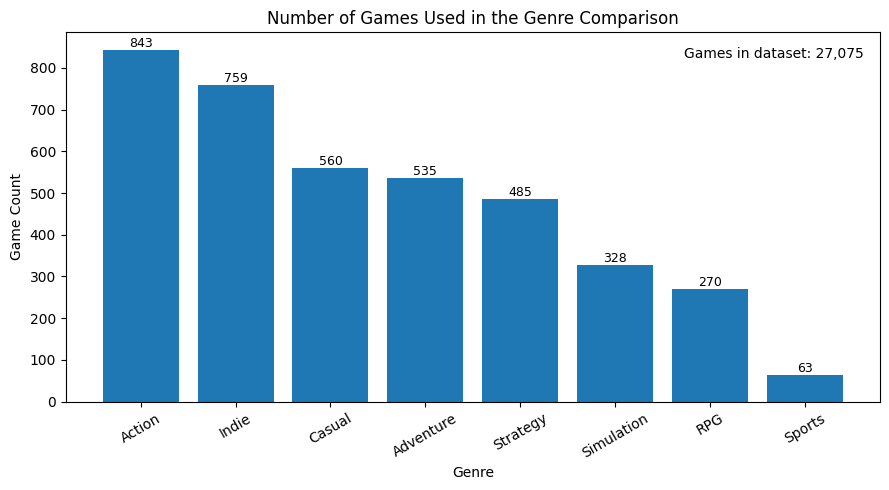

In [20]:
import matplotlib.pyplot as plt

plot_data = (
    genre_summary
    .sort_values(
        "game_count",
        ascending=False,
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    plot_data["genre"],
    plot_data["game_count"],
)


ax.set_title(
    "Number of Games Used in the Genre Comparison"
)

ax.set_xlabel(
    "Genre"
)

ax.set_ylabel(
    "Game Count"
)

ax.tick_params(
    axis="x",
    rotation=30,
)


for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.text(
    0.98,
    0.96,
    (
        f"Games in dataset: {len(steam):,}\n"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
)


plt.tight_layout()
plt.show()

## Conclusion

Sports has the highest mean listed price among the eight genres analyzed, with an average price of $13.80.